# LIBRARY IMPORT

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 15.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_model import ARIMAResults
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox



In [ ]:
sns.set_style('darkgrid')

In [ ]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\nADF Test: {name}")
    print("-"*40)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    for key, val in result[4].items():
        print(f"Critical Value ({key}): {val}")
    if result[1] < 0.05:
        print("Conclusion: Stationary")
    else:
        print("Conclusion: Non-stationary")



In [ ]:
def kpss_test(series, name):
    stat, p, lags, crit = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"KPSS Test: {name}")
    print("-"*40)
    print(f"KPSS Statistic : {stat:.4f}")
    print(f"p-value        : {p:.4f}")
    for k, v in crit.items():
        print(f"Critical Value ({k}): {v:.4f}")
    # KPSS: H0 = stationary, so p < 0.05 means NON-stationary
    if p < 0.05:
        print("Conclusion: Non-stationary (reject H0 of stationarity)")
    else:
        print("Conclusion: Stationary (fail to reject H0)")



# DOWNLOAD DATASET

In [ ]:
path = kagglehub.dataset_download("ibrahimshahrukh/coca-cola-ko-stock-prices-19802026")

print("Path to dataset files:", path)

100%|██████████| 720k/720k [00:00<00:00, 33.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ibrahimshahrukh/coca-cola-ko-stock-prices-19802026/versions/1


In [ ]:
os.listdir(path)

['KO_CocaCola_Stock_Prices_1980_2026.csv']

In [ ]:
df=pd.read_csv(os.path.join(path,'KO_CocaCola_Stock_Prices_1980_2026.csv'))

In [ ]:
df=pd.read_csv(os.path.join(path,'goldstock v1.csv'))

In [ ]:
df=pd.read_csv(os.path.join(path,'googl_daily_prices.csv'))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/gold-stock-prices/googl_daily_prices.csv'

In [ ]:
df=df[-500:].reset_index(drop=True)

In [ ]:
len(df)

500

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   500 non-null    object 
 1   Open                   500 non-null    float64
 2   High                   500 non-null    float64
 3   Low                    500 non-null    float64
 4   Close                  500 non-null    float64
 5   Volume                 500 non-null    int64  
 6   Daily_Return_Pct       500 non-null    float64
 7   Daily_Range            500 non-null    float64
 8   MA_20                  500 non-null    float64
 9   MA_50                  500 non-null    float64
 10  MA_200                 500 non-null    float64
 11  EMA_12                 500 non-null    float64
 12  EMA_26                 500 non-null    float64
 13  MACD                   500 non-null    float64
 14  MACD_Signal            500 non-null    float64
 15  BB_Upp

In [ ]:
df.rename(columns={'4. close':'Close'}, inplace=True)

# EDA

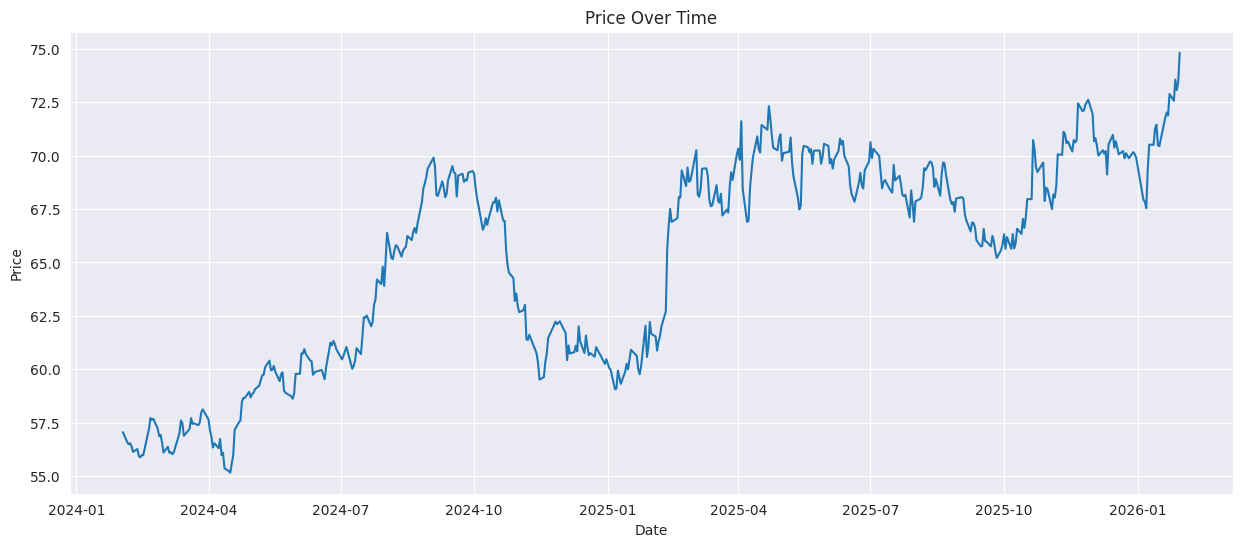

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
plt.figure(figsize=(15,6))
plt.plot(df['Date'], df['Close'])
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Price Over Time")
plt.show()

In [ ]:
df['Close'].describe()

,Close
count,500.000000
mean,65.205269
std,4.875829
min,55.162500
25%,60.699750
50%,66.926550
75%,69.282725
max,74.810000


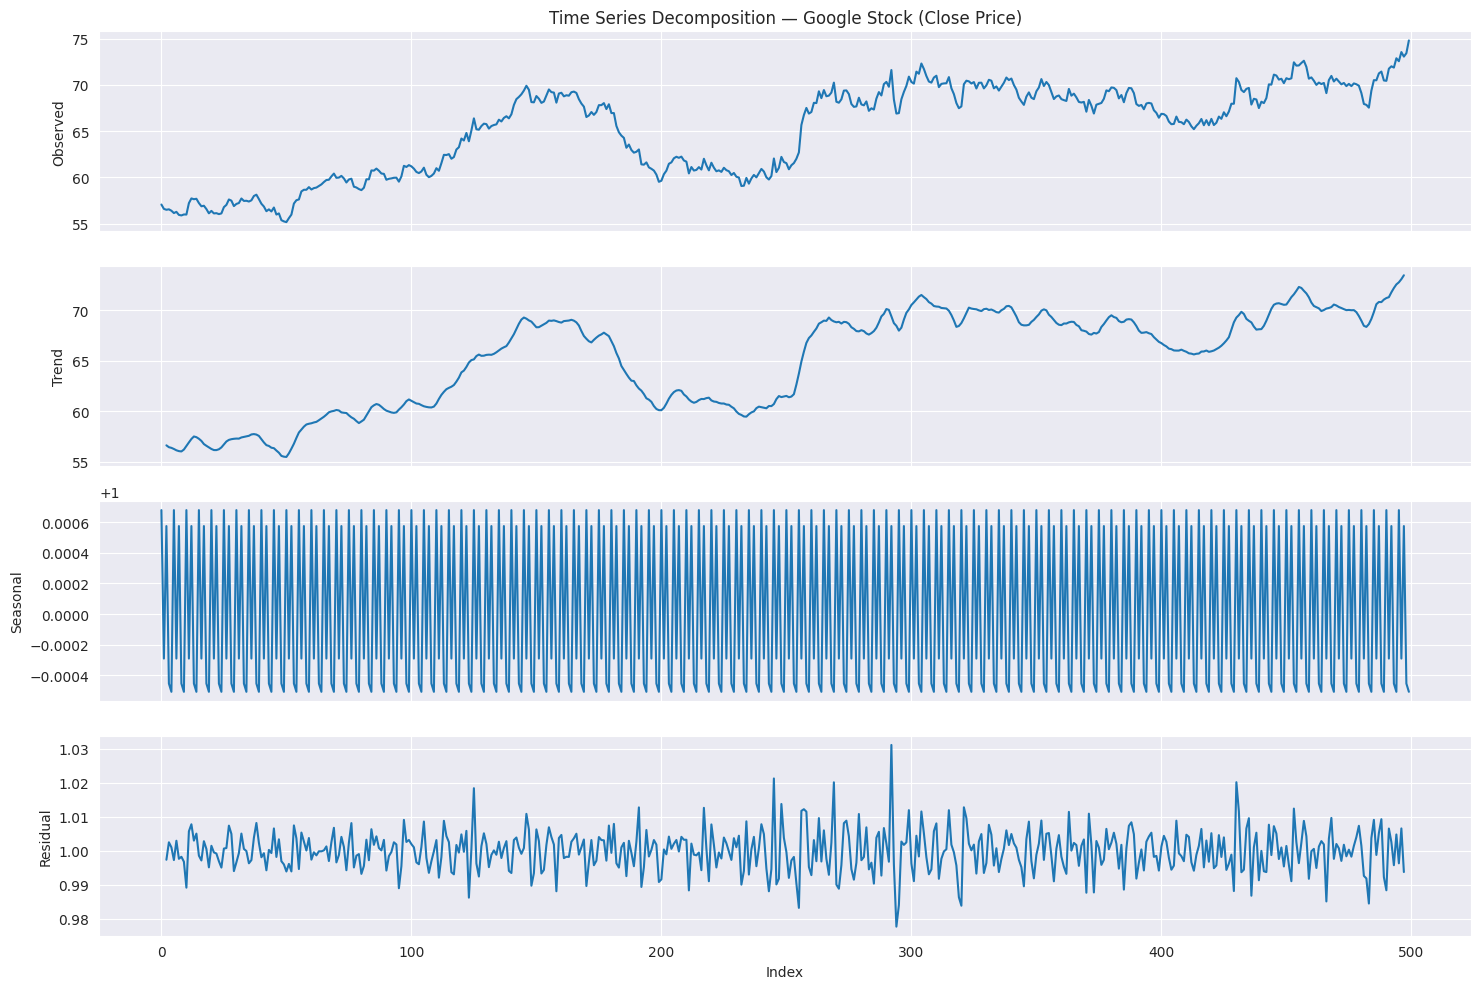

=== Decomposition Summary ===
Trend   — mean: 65.2042,  std: 4.7997
Seasonal— mean: 1.0000,  std: 0.0005
Residual— mean: 1.0000,  std: 0.0061


In [ ]:

decomposition = seasonal_decompose(df['Close'], model='multiplicative', period=5)  # period=5 for weekly trading cycle

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

decomposition.observed.plot(ax=axes[0])
axes[0].set_ylabel('Observed')
axes[0].set_title('Time Series Decomposition — Google Stock (Close Price)')

decomposition.trend.plot(ax=axes[1])
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2])
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3])
axes[3].set_ylabel('Residual')

plt.xlabel('Index')
plt.tight_layout()
plt.show()

# Print summary stats for each component
print("=== Decomposition Summary ===")
print(f"Trend   — mean: {decomposition.trend.dropna().mean():.4f},  std: {decomposition.trend.dropna().std():.4f}")
print(f"Seasonal— mean: {decomposition.seasonal.mean():.4f},  std: {decomposition.seasonal.std():.4f}")
print(f"Residual— mean: {decomposition.resid.dropna().mean():.4f},  std: {decomposition.resid.dropna().std():.4f}")

<Axes: xlabel='Close', ylabel='Count'>

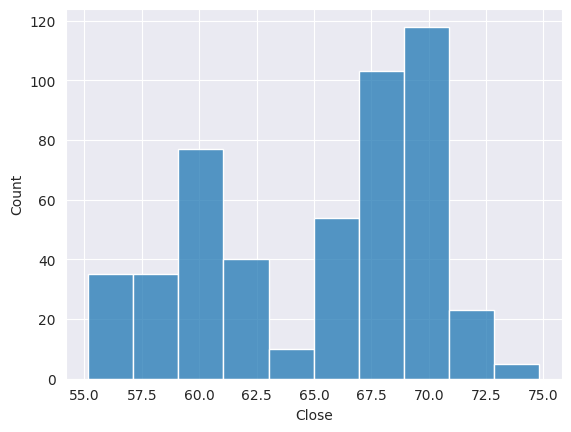

In [ ]:
sns.histplot(df['Close'])

<Axes: ylabel='Close'>

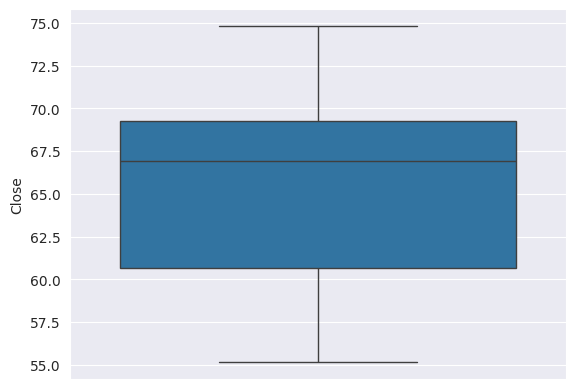

In [ ]:
sns.boxplot(df['Close'])

In [ ]:
adf_test(df['Close'], "Close")


ADF Test: Close
----------------------------------------
ADF Statistic: -1.3082178332228445
p-value: 0.6254043087390899
Critical Value (1%): -3.4435228622952065
Critical Value (5%): -2.867349510566146
Critical Value (10%): -2.569864247011056
Conclusion: Non-stationary


In [ ]:
kpss_test(df['Close'], "Close")

KPSS Test: Close
----------------------------------------
KPSS Statistic : 2.6221
p-value        : 0.0100
Critical Value (10%): 0.3470
Critical Value (5%): 0.4630
Critical Value (2.5%): 0.5740
Critical Value (1%): 0.7390
Conclusion: Non-stationary (reject H0 of stationarity)


/tmp/ipykernel_4391/3833783288.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, lags, crit = kpss(series.dropna(), regression="c", nlags="auto")


# PREPROCESSING AND CHOOSING PARAMETERS

In [ ]:
series=df['Close']
log_diff = np.log(series).diff().dropna()
#log_diff = series.diff().#dropna()

In [ ]:
log_diff.describe()

,Close
count,499.000000
mean,0.054270
std,0.978789
min,-4.542801
25%,-0.547597
50%,0.027957
75%,0.598005
max,4.616799


In [ ]:
log_diff

,Close
1,-0.008294
2,-0.001668
3,0.000835
4,-0.002671
5,-0.004523
...,...
495,-0.004400
496,0.013552
497,-0.006684
498,0.005052


In [ ]:
adf_test(log_diff, "Close")


ADF Test: Close
----------------------------------------
ADF Statistic: -22.76851259087463
p-value: 0.0
Critical Value (1%): -3.4435494520411605
Critical Value (5%): -2.8673612117611267
Critical Value (10%): -2.5698704830567247
Conclusion: Stationary


In [ ]:
kpss_test(log_diff[-1000:], "Close")

KPSS Test: Close
----------------------------------------
KPSS Statistic : 0.0518
p-value        : 0.1000
Critical Value (10%): 0.3470
Critical Value (5%): 0.4630
Critical Value (2.5%): 0.5740
Critical Value (1%): 0.7390
Conclusion: Stationary (fail to reject H0)


/tmp/ipykernel_4391/3833783288.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, crit = kpss(series.dropna(), regression="c", nlags="auto")


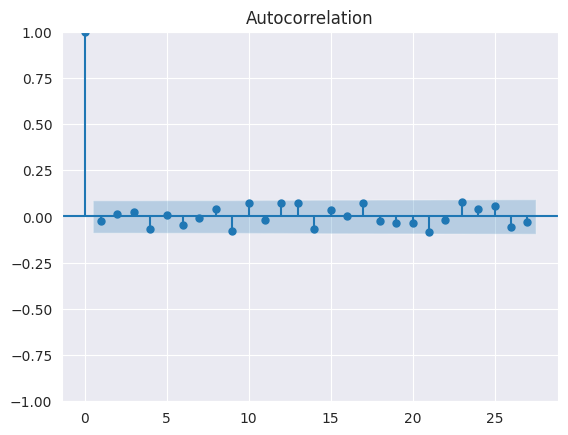

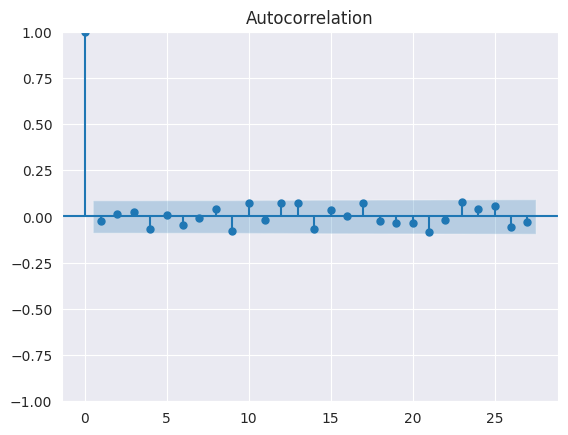

In [ ]:
plot_acf (log_diff)

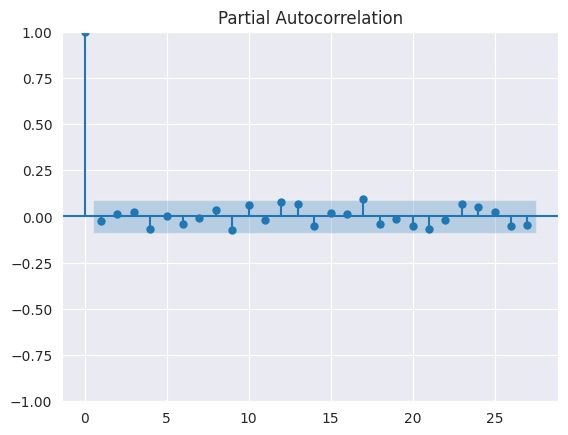

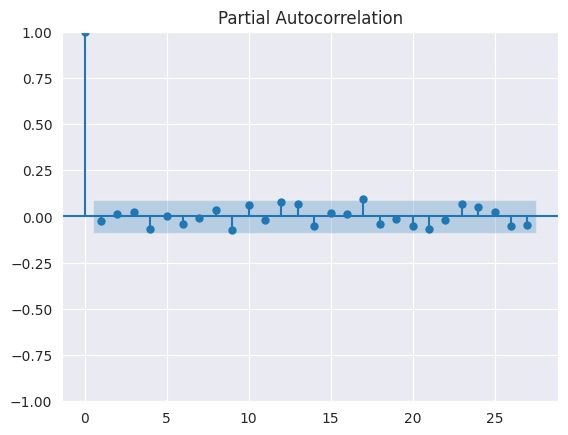

In [ ]:
plot_pacf (log_diff)

# LINEAR MODELS

In [ ]:
train = log_diff[:-100]
test = log_diff[-100:]

## MA

In [ ]:
ma= ARIMA (log_diff,order=( 0,0,1)).fit()
print(ma.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  499
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -696.705
Date:                Mon, 27 Apr 2026   AIC                           1399.410
Time:                        11:08:44   BIC                           1412.048
Sample:                             0   HQIC                          1404.369
                                - 499                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0542      0.044      1.237      0.216      -0.032       0.140
ma.L1         -0.0240      0.037     -0.640      0.522      -0.097       0.049
sigma2         0.9555      0.042     22.627      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

RMSE: 2.3001
MAE:  1.9055
MAPE: 2.70%


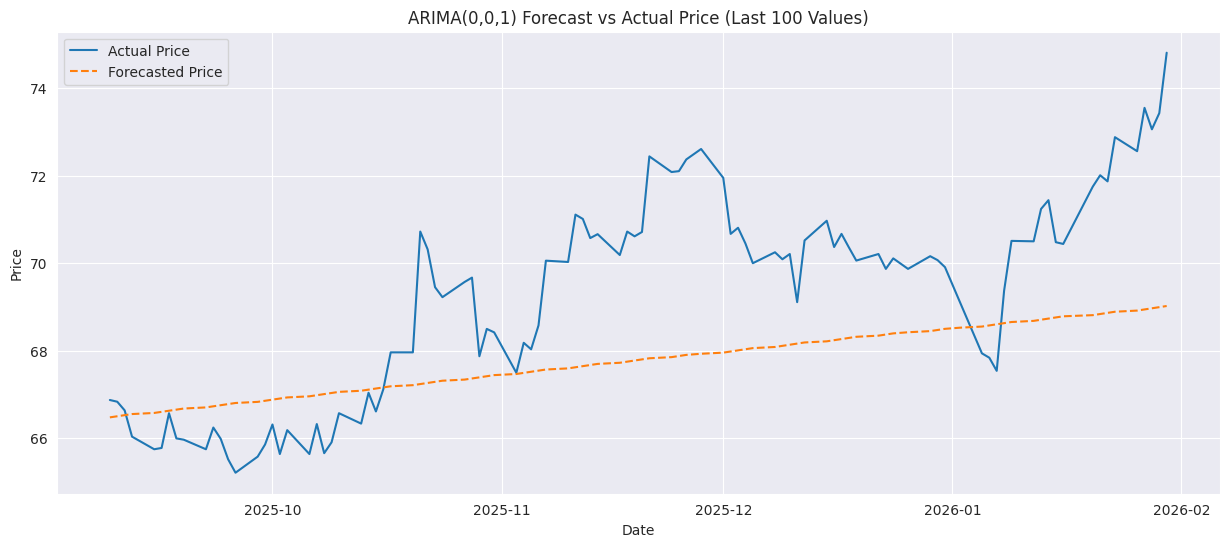

In [ ]:

model = ARIMA(train, order=(0,0,1)).fit()
forecast = model.forecast(steps=100)

# -----------------------------
# Inverse transform to Price
# -----------------------------
# Last known actual price before forecast starts
last_price = df['Close'].iloc[-101]

# Convert predicted log returns -> price path
pred_price = last_price * np.exp(np.cumsum(forecast))

# Actual prices for last 100 points
actual_price = df['Close'].iloc[-100:].values
dates = df['Date'].iloc[-100:]

# -----------------------------
# Metrics on Price Scale
# -----------------------------
rmse = np.sqrt(mean_squared_error(actual_price, pred_price))
mae = mean_absolute_error(actual_price, pred_price)
mape = np.mean(np.abs((actual_price - pred_price) / actual_price)) * 100

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.2f}%")

# -----------------------------
# Plot Actual vs Predicted Price
# -----------------------------
plt.figure(figsize=(15,6))
plt.plot(dates, actual_price, label="Actual Price")
plt.plot(dates, pred_price, '--', label="Forecasted Price")

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("ARIMA(0,0,1) Forecast vs Actual Price (Last 100 Values)")
plt.legend()
plt.grid(True)
plt.show()

## AR

In [ ]:
AR= ARIMA (log_diff,order=( 1,0,0)).fit()
print(AR.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  499
Model:                 ARIMA(1, 0, 0)   Log Likelihood                1601.280
Date:                Mon, 20 Apr 2026   AIC                          -3196.559
Time:                        13:14:29   BIC                          -3183.921
Sample:                             0   HQIC                         -3191.600
                                - 499                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.237      0.216      -0.000       0.001
ar.L1         -0.0247      0.037     -0.664      0.507      -0.098       0.048
sigma2      9.556e-05   4.22e-06     22.617      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

RMSE: 2.2964
MAE:  1.9024
MAPE: 2.70%


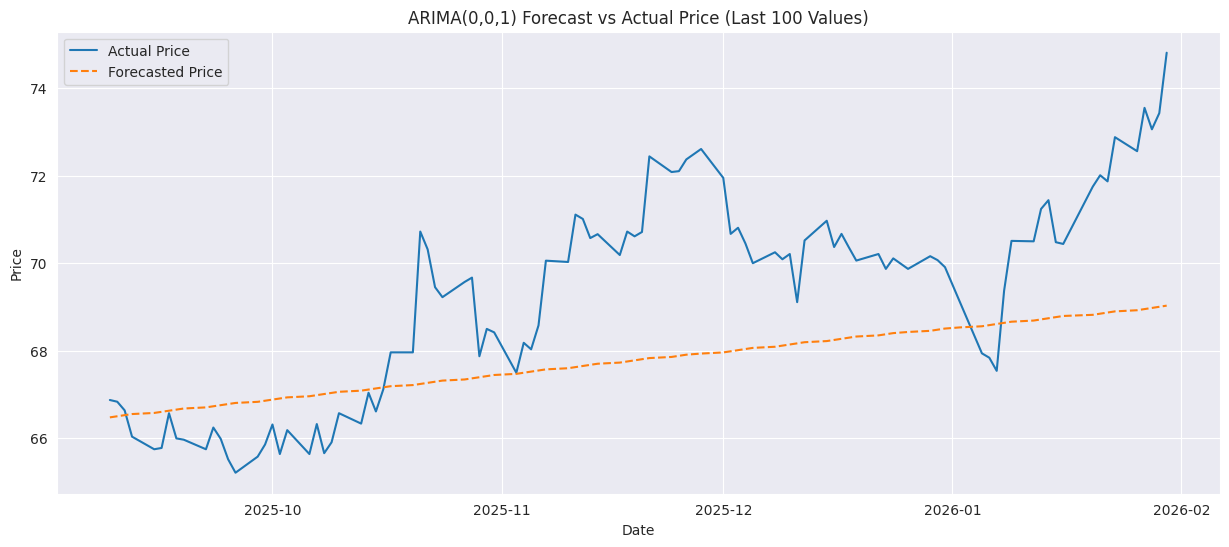

In [ ]:

model = ARIMA(train, order=(1,0,0)).fit()
forecast = model.forecast(steps=100)

# -----------------------------
# Inverse transform to Price
# -----------------------------
# Last known actual price before forecast starts
last_price = df['Close'].iloc[-101]

# Convert predicted log returns -> price path
pred_price = last_price * np.exp(np.cumsum(forecast))

# Actual prices for last 100 points
actual_price = df['Close'].iloc[-100:].values
dates = df['Date'].iloc[-100:]

# -----------------------------
# Metrics on Price Scale
# -----------------------------
rmse = np.sqrt(mean_squared_error(actual_price, pred_price))
mae = mean_absolute_error(actual_price, pred_price)
mape = np.mean(np.abs((actual_price - pred_price) / actual_price)) * 100

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.2f}%")

# -----------------------------
# Plot Actual vs Predicted Price
# -----------------------------
plt.figure(figsize=(15,6))
plt.plot(dates, actual_price, label="Actual Price")
plt.plot(dates, pred_price, '--', label="Forecasted Price")

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("ARIMA(0,0,1) Forecast vs Actual Price (Last 100 Values)")
plt.legend()
plt.grid(True)
plt.show()

## ARMA

In [ ]:
ARMA= ARIMA (log_diff,order=( 1,0,1)).fit()
print(ARMA.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  499
Model:                 ARIMA(1, 0, 1)   Log Likelihood                1601.285
Date:                Mon, 20 Apr 2026   AIC                          -3194.570
Time:                        13:14:32   BIC                          -3177.719
Sample:                             0   HQIC                         -3187.957
                                - 499                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.230      0.219      -0.000       0.001
ar.L1         -0.0578      1.818     -0.032      0.975      -3.621       3.506
ma.L1          0.0326      1.826      0.018      0.9

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

RMSE: 2.3003
MAE:  1.9056
MAPE: 2.70%


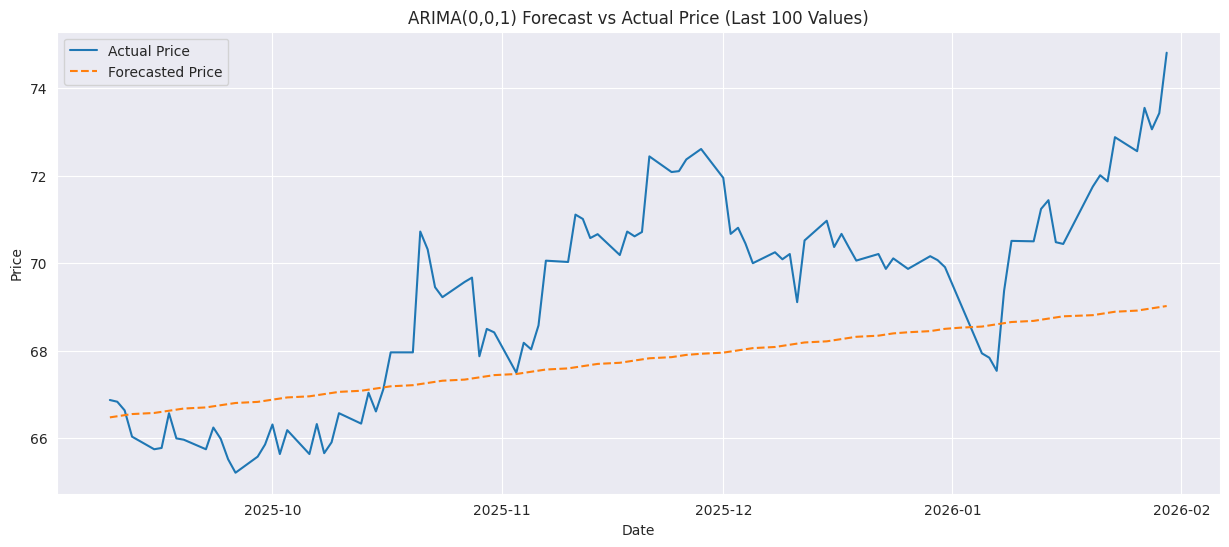

In [ ]:

model = ARIMA(train, order=(1,0,1)).fit()
forecast = model.forecast(steps=100)

# -----------------------------
# Inverse transform to Price
# -----------------------------
# Last known actual price before forecast starts
last_price = df['Close'].iloc[-101]

# Convert predicted log returns -> price path
pred_price = last_price * np.exp(np.cumsum(forecast))

# Actual prices for last 100 points
actual_price = df['Close'].iloc[-100:].values
dates = df['Date'].iloc[-100:]

# -----------------------------
# Metrics on Price Scale
# -----------------------------
rmse = np.sqrt(mean_squared_error(actual_price, pred_price))
mae = mean_absolute_error(actual_price, pred_price)
mape = np.mean(np.abs((actual_price - pred_price) / actual_price)) * 100

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.2f}%")

# -----------------------------
# Plot Actual vs Predicted Price
# -----------------------------
plt.figure(figsize=(15,6))
plt.plot(dates, actual_price, label="Actual Price")
plt.plot(dates, pred_price, '--', label="Forecasted Price")

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("ARIMA(0,0,1) Forecast vs Actual Price (Last 100 Values)")
plt.legend()
plt.grid(True)
plt.show()

## ARIMA

In [ ]:
arima= ARIMA (log_diff,order=( 1,1,1)).fit()
print(arima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  499
Model:                 ARIMA(1, 1, 1)   Log Likelihood                1594.440
Date:                Mon, 27 Apr 2026   AIC                          -3182.879
Time:                        02:11:35   BIC                          -3170.247
Sample:                             0   HQIC                         -3177.922
                                - 499                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0226      0.037     -0.616      0.538      -0.095       0.049
ma.L1         -0.9997      0.150     -6.656      0.000      -1.294      -0.705
sigma2      9.568e-05   1.58e-05      6.064      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retv

RMSE: 2.2957
MAE:  1.9017
MAPE: 2.70%


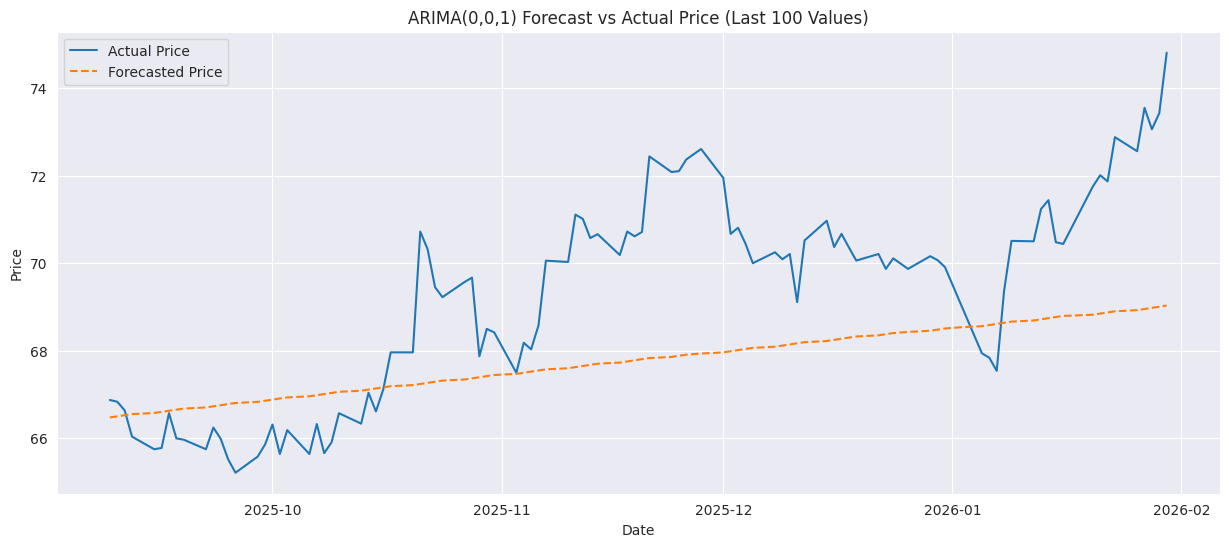

In [ ]:

model = ARIMA(train, order=(1,1,1)).fit()
forecast = model.forecast(steps=100)

# -----------------------------
# Inverse transform to Price
# -----------------------------
# Last known actual price before forecast starts
last_price = df['Close'].iloc[-101]

# Convert predicted log returns -> price path
pred_price = last_price * np.exp(np.cumsum(forecast))

# Actual prices for last 100 points
actual_price = df['Close'].iloc[-100:].values
dates = df['Date'].iloc[-100:]

# -----------------------------
# Metrics on Price Scale
# -----------------------------
rmse = np.sqrt(mean_squared_error(actual_price, pred_price))
mae = mean_absolute_error(actual_price, pred_price)
mape = np.mean(np.abs((actual_price - pred_price) / actual_price)) * 100

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.2f}%")

# -----------------------------
# Plot Actual vs Predicted Price
# -----------------------------
plt.figure(figsize=(15,6))
plt.plot(dates, actual_price, label="Actual Price")
plt.plot(dates, pred_price, '--', label="Forecasted Price")

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("ARIMA(0,0,1) Forecast vs Actual Price (Last 100 Values)")
plt.legend()
plt.grid(True)
plt.show()

# NONLINEAR MODELS


## CHOOSE Q FOR ARCH

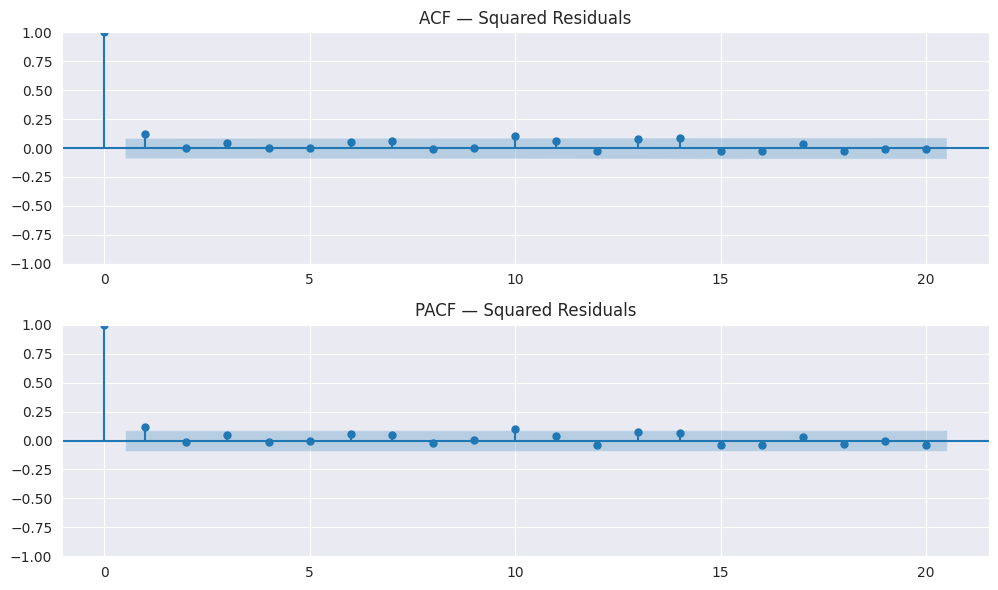

In [ ]:
resid = arima.resid

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(resid**2,  lags=20, ax=axes[0], title="ACF — Squared Residuals")
plot_pacf(resid**2, lags=20, ax=axes[1], title="PACF — Squared Residuals")
plt.tight_layout()
plt.show()



## ARCH

In [ ]:
log_diff*=100

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -693.434
Distribution:                  Normal   AIC:                           1392.87
Method:            Maximum Likelihood   BIC:                           1405.51
                                        No. Observations:                  499
Date:                Mon, Apr 27 2026   Df Residuals:                      498
Time:                        10:18:11   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0490  4.385e-02      1.118      0.264 [-3.69

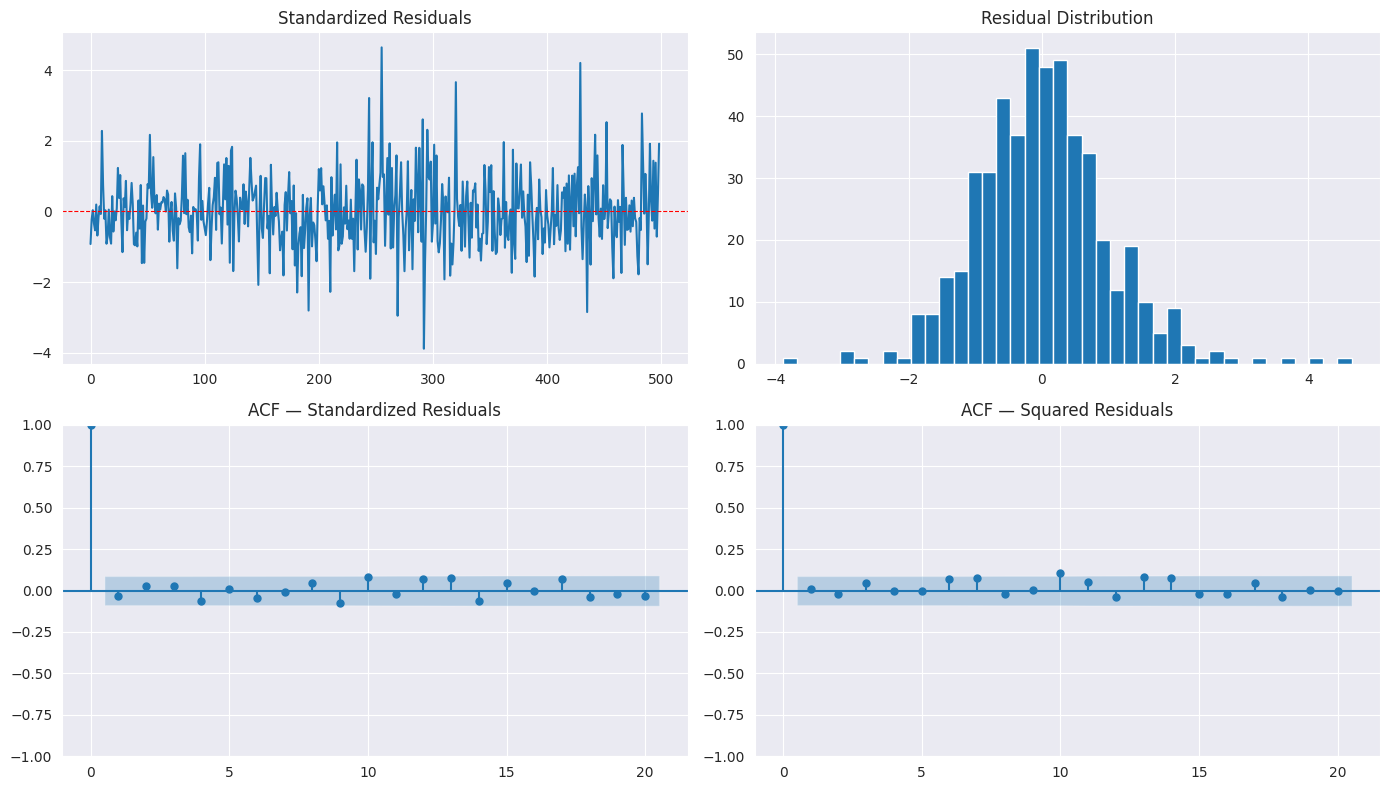

In [ ]:
мa_model = arch_model(log_diff, vol='arch', p=1, q=1)
a_fit = a_model.fit(disp='off')
print(a_fit.summary())



std_resid_arch = a_fit.resid / a_fit.conditional_volatility

lb_resid = acorr_ljungbox(std_resid_arch.dropna(), lags=[5, 10, 15], return_df=True)
print("\nLjung-Box — standardized residuals:")
print(lb_resid)

lb_sq = acorr_ljungbox(std_resid_arch.dropna()**2, lags=[5, 10, 15], return_df=True)
print("\nLjung-Box — squared standardized residuals:")
print(lb_sq)

# ── Diagnostic plot ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(std_resid_arch.values)
axes[0, 0].set_title('Standardized Residuals')
axes[0, 0].axhline(0, color='red', linewidth=0.8, linestyle='--')

axes[0, 1].hist(std_resid_arch.dropna(), bins=40, edgecolor='white')
axes[0, 1].set_title('Residual Distribution')

plot_acf(std_resid_arch.dropna(), lags=20, ax=axes[1, 0], title='ACF — Standardized Residuals')
plot_acf(std_resid_arch.dropna()**2, lags=20, ax=axes[1, 1], title='ACF — Squared Residuals')

plt.tight_layout()
plt.show()

## GARCH

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -685.634
Distribution:                  Normal   AIC:                           1379.27
Method:            Maximum Likelihood   BIC:                           1396.12
                                        No. Observations:                  499
Date:                Mon, Apr 27 2026   Df Residuals:                      498
Time:                        10:17:12   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0537  4.384e-02      1.225      0.220 [-3.22

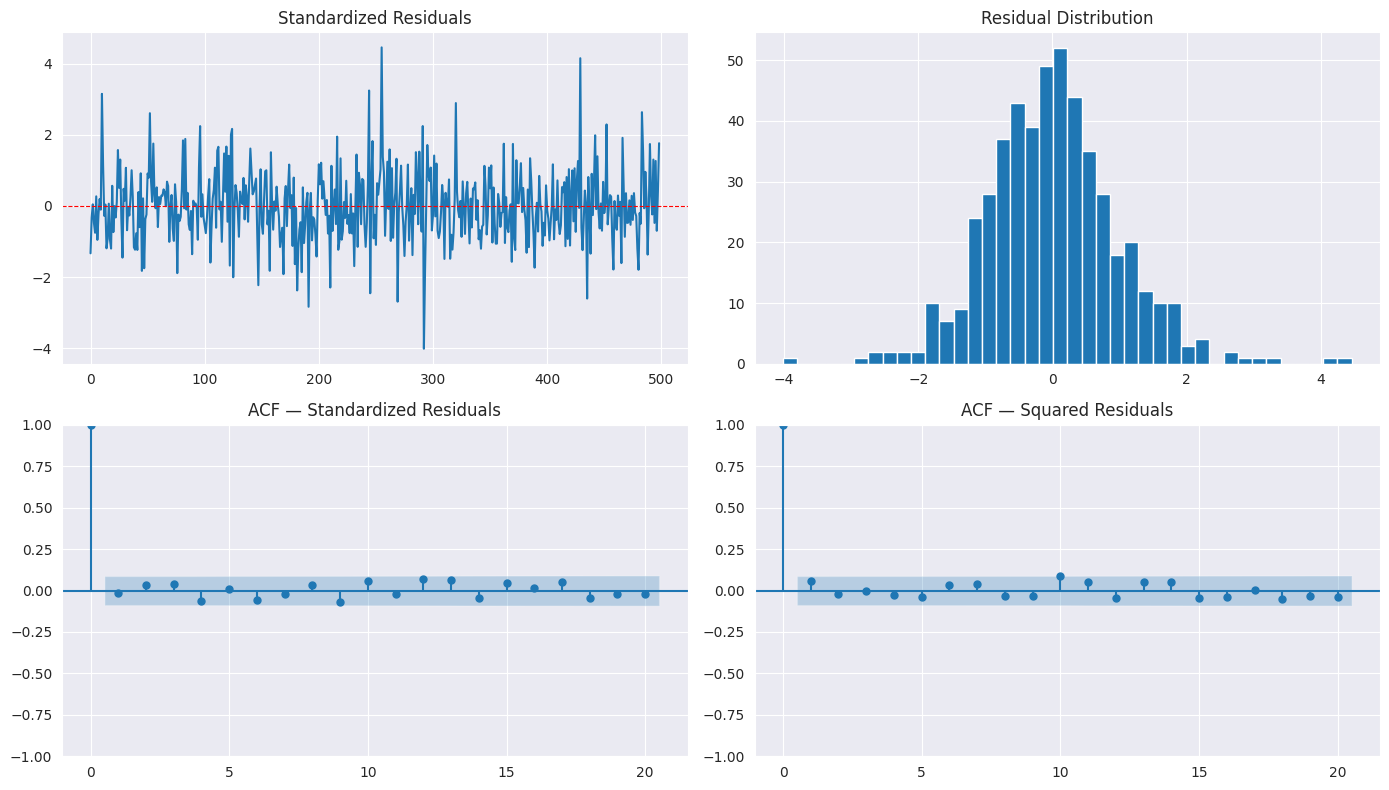

In [ ]:
ga_model = arch_model(log_diff, vol='Garch', p=1, q=1)
ga_fit = ga_model.fit(disp='off')
print(ga_fit.summary())


std_resid = ga_fit.resid / ga_fit.conditional_volatility

lb_resid = acorr_ljungbox(std_resid.dropna(), lags=[5, 10, 15], return_df=True)
print("\nLjung-Box — standardized residuals:")
print(lb_resid)

lb_sq = acorr_ljungbox(std_resid.dropna()**2, lags=[5, 10, 15], return_df=True)
print("\nLjung-Box — squared standardized residuals:")
print(lb_sq)

# ── Diagnostic plot ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(std_resid.values)
axes[0, 0].set_title('Standardized Residuals')
axes[0, 0].axhline(0, color='red', linewidth=0.8, linestyle='--')

axes[0, 1].hist(std_resid.dropna(), bins=40, edgecolor='white')
axes[0, 1].set_title('Residual Distribution')

plot_acf(std_resid.dropna(), lags=20, ax=axes[1, 0], title='ACF — Standardized Residuals')
plot_acf(std_resid.dropna()**2, lags=20, ax=axes[1, 1], title='ACF — Squared Residuals')

plt.tight_layout()
plt.show()

# LSTM (EXTRA CREDIT)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from keras import layers, callbacks, optimizers
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM, Dense, Dropout


tf.random.set_seed(42)
np.random.seed(42)

## PREPROCCESSING

In [ ]:
close = df["Close"].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(close)

# ── 2. Sequences from Close ──────────────────────────────
LOOKBACK = 16

def make_sequences(data, lookback=LOOKBACK):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X)[..., np.newaxis], np.array(y)

# ── 3. Train / val / test split ─────────────────────────
n = len(scaled)
t_end = int(n * 0.75)
v_end = int(n * 0.80)

train_s = scaled[:t_end]
val_s   = scaled[t_end - LOOKBACK:v_end]
test_s  = scaled[v_end - LOOKBACK:]

X_train, y_train = make_sequences(train_s)
X_val, y_val     = make_sequences(val_s)
X_test, y_test   = make_sequences(test_s)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)



Train: (359, 16, 1) (359,)
Val  : (25, 16, 1) (25,)
Test : (100, 16, 1) (100,)


In [ ]:
len(y_test)

100

## MODEL FIT & TESTING

In [ ]:
model = Sequential([
    LSTM(128, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

# ── 5. Train ─────────────────────────────────────────────
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    shuffle=False,
    callbacks=[
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-7,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath="best_close_lstm.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),
    ],
    verbose=1,
)

print(history.history.keys())
print(f"Stopped at epoch : {len(history.history['loss'])}")
print(f"Best val_loss    : {min(history.history['val_loss']):.6f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,689 (260.50 KB)

 Trainable params: 66,689 (260.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1057 - mae: 0.2745
Epoch 1: val_loss improved from None to 0.04071, saving model to best_close_lstm.keras

Epoch 1: finished saving model to best_close_lstm.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - loss: 0.1381 - mae: 0.3342 - val_loss: 0.0407 - val_mae: 0.1956 - learning_rate: 0.0010
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0110 - mae: 0.0830
Epoch 2: val_loss improved from 0.04071 to 0.02013, saving model to best_close_lstm.keras

Epoch 2: finished saving model to best_close_lstm.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0186 - mae: 0.1119 - val_loss: 0.0201 - val_mae: 0.1322 - learning_rate: 0.0010
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0149 - mae: 0.1047
Epoch 3: val_loss improved from 0.02013 to 0.00972, saving model to best_close_lstm.keras

Epoch 3: finished saving model to best_close_lstm.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0124 - mae: 0.0923 -

TEST PERFORMANCE
RMSE : 1.2368
MAE  : 0.9772
MAPE : 1.40%
R²   : 0.7155

First 10 Predictions:
        Date   Actual  Predicted     Error
0 2025-09-09  66.8738  67.513771 -0.639971
1 2025-09-10  66.8344  67.322342 -0.487942
2 2025-09-11  66.6373  67.154915 -0.517615
3 2025-09-12  66.0362  67.014305 -0.978105
4 2025-09-15  65.7482  66.861725 -1.113525
5 2025-09-16  65.7780  66.677925 -0.899925
6 2025-09-17  66.5724  66.482338  0.090062
7 2025-09-18  65.9965  66.340523 -0.344023
8 2025-09-19  65.9667  66.241173 -0.274473
9 2025-09-22  65.7482  66.157860 -0.409660


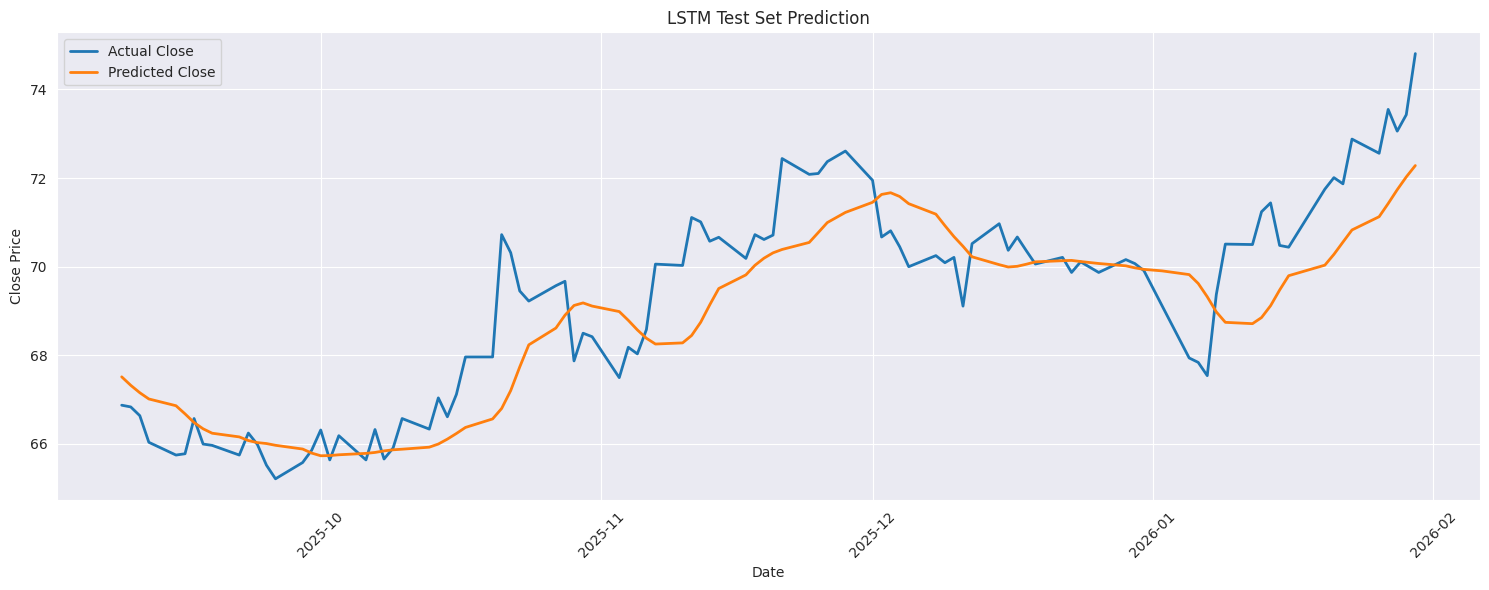

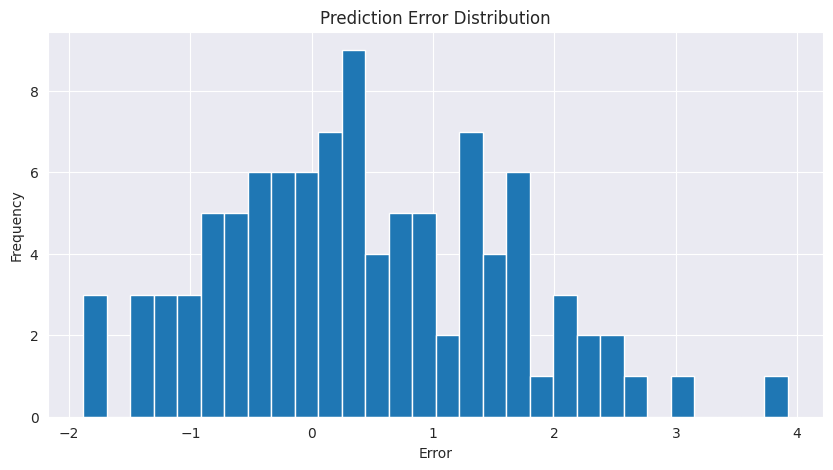

In [ ]:
y_pred_scaled = model.predict(X_test, verbose=0)

# 2. Convert scaled values back to original prices
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_real = scaler.inverse_transform(y_pred_scaled)

# 3. Metrics
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae  = mean_absolute_error(y_test_real, y_pred_real)
r2   = r2_score(y_test_real, y_pred_real)
mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

print("=" * 50)
print("TEST PERFORMANCE")
print("=" * 50)
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

# 4. Results table with last matching dates
results = pd.DataFrame({
    "Date": df["Date"].iloc[-len(y_test_real):].values,
    "Actual": y_test_real.flatten(),
    "Predicted": y_pred_real.flatten(),
    "Error": y_test_real.flatten() - y_pred_real.flatten()
})

print("\nFirst 10 Predictions:")
print(results.head(10))

# 5. Plot Actual vs Predicted using Date as x-axis
plt.figure(figsize=(15,6))
plt.plot(results["Date"], results["Actual"], label="Actual Close", linewidth=2)
plt.plot(results["Date"], results["Predicted"], label="Predicted Close", linewidth=2)
plt.title("LSTM Test Set Prediction")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Error histogram
plt.figure(figsize=(10,5))
plt.hist(results["Error"], bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()